In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/bank-data.zip"
!ls

Archive:  /content/drive/MyDrive/bank-data.zip
   creating: bank-data/
  inflating: __MACOSX/._bank-data    
  inflating: bank-data/.DS_Store     
  inflating: __MACOSX/bank-data/._.DS_Store  
  inflating: bank-data/bank-full.csv  
  inflating: __MACOSX/bank-data/._bank-full.csv  
bank-data  drive  __MACOSX  sample_data


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

In [7]:
df = pd.read_csv('bank-data/bank-full.csv', sep=';')

print("Dataset Info:\n")
print(df.info())

print("\nFirst 5 Rows:\n")
print(df.head())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

First 5 Rows:

   age           job  marital  education default  balance housi


Target Value Counts:

y
no     39922
yes     5289
Name: count, dtype: int64


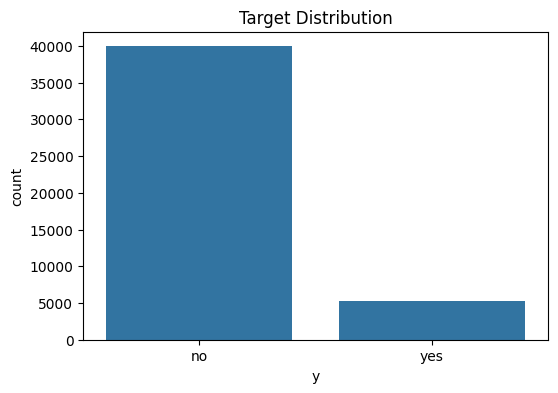

In [8]:
print("\nTarget Value Counts:\n")
print(df['y'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='y', data=df)
plt.title("Target Distribution")
plt.show()


In [9]:
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# One-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

# Features and target
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\n Preprocessing complete.\n")


 Preprocessing complete.



In [11]:
# Using class_weight='balanced' for imbalance handling
logmodel = LogisticRegression(max_iter=1000, class_weight='balanced')
logmodel.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [12]:
predictions = logmodel.predict(X_test)


--- Confusion Matrix ---
[[6715 1237]
 [ 185  906]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      7952
           1       0.42      0.83      0.56      1091

    accuracy                           0.84      9043
   macro avg       0.70      0.84      0.73      9043
weighted avg       0.91      0.84      0.86      9043

Accuracy: 0.8427512993475617


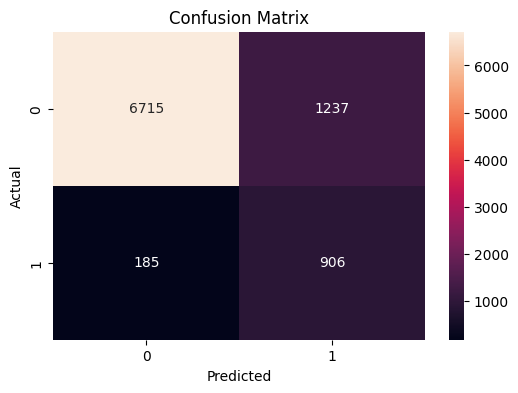

In [13]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, predictions)
print(cm)

print("\n--- Classification Report ---")
print(classification_report(y_test, predictions))

print("Accuracy:", accuracy_score(y_test, predictions))

# Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

